# STAIR Evaluation Graphs

This notebook evaluates three claims:

1. STAIR is correct: folded/reused schedules preserve the original output bitwidth semantics.
2. STAIR enables design-space exploration: the fold factor is swept systematically.
3. STAIR estimates are meaningful: STAIR/DA4ML LUT estimates are compared against real FPGA results.

The notebook reads real post-route Vivado reports from `official_models/3-feature-perminv` and `official_models/16-feature-perminv`.
It then runs the full STAIR pipeline for every model and fold factor:

```python
model = load_keras_model(model_path)
nn_graph = build_nn_ir_graph(model)
design = evaluate_folded_design(nn_graph, model, fold_factor=fold_factor)
correctness = check_correctness(design, model)
```

Only `fold_factor == 1` is used for LUT validation against the real spatial hardware baseline. Correctness is checked for all fold factors.

In [2]:
%matplotlib inline

from __future__ import annotations

import json
import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle

plt.rcParams.update({
    "figure.figsize": (8.5, 5.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

HERE = Path.cwd()
for candidate in [HERE, HERE.parent, HERE.parent.parent]:
    if (candidate / "official_models").exists() and (candidate / "IR").exists():
        REPO = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate the CMIR repository root.")

sys.path.insert(0, str(REPO))

MODEL_ROOTS = {
    "3-feature": REPO / "official_models" / "3-feature-perminv",
    "16-feature": REPO / "official_models" / "16-feature-perminv",
}
FOLD_FACTORS = [1, 2, 4, 8, 16]
TARGET_FMAX_HZ = 300e6
STAIR_RESULTS_CACHE = REPO / "IR" / "stair_pipeline_results.csv"
FORCE_REBUILD_STAIR = True

print(f"Repository: {REPO}")
print(f"STAIR cache: {STAIR_RESULTS_CACHE.relative_to(REPO)}")

Repository: /Users/sriharshavitta/Projects/CMIR
STAIR cache: IR/stair_pipeline_results.csv


## Real Hardware Results

LUTs, FFs, BRAMs and DSPs are parsed from Vivado post-route utilization reports. Achieved `Fmax` is derived from timing slack:

`Fmax = 1000 / (clock_period_constraint_ns - WNS_ns)`

Latency is the number of generated pipeline stages multiplied by the achieved clock period. The generated DA4ML designs are fully pipelined, so the hardware baseline has `II = 1`.

In [3]:
def _parse_int_cell(text: str, row_name: str) -> int | None:
    pattern = rf"\|\s*{re.escape(row_name)}\s*\|\s*([\d,]+)"
    match = re.search(pattern, text)
    return int(match.group(1).replace(",", "")) if match else None


def _parse_timing_summary(text: str) -> dict[str, float]:
    wns_match = re.search(
        r"\n\s*([-+]?\d+\.\d+)\s+[-+]?\d+\.\d+\s+\d+\s+\d+",
        text,
    )
    period_match = re.search(r"sys_clk\s+\{[^}]+\}\s+(\d+\.\d+)\s+", text)
    if not wns_match or not period_match:
        return {"wns_ns": np.nan, "period_constraint_ns": np.nan, "achieved_period_ns": np.nan, "fmax_mhz": np.nan}
    wns = float(wns_match.group(1))
    period = float(period_match.group(1))
    achieved_period = period - wns
    return {
        "wns_ns": wns,
        "period_constraint_ns": period,
        "achieved_period_ns": achieved_period,
        "fmax_mhz": 1000.0 / achieved_period,
    }


def _parse_output_width(verilog_text: str) -> int | None:
    match = re.search(r"output\s+reg\s+\[(\d+)\s*:\s*0\]\s+out", verilog_text)
    return int(match.group(1)) + 1 if match else None


def _model_artifact(model_dir: Path) -> str | None:
    models = sorted((model_dir / "models").glob("*.keras"))
    return str(models[-1].relative_to(REPO)) if models else None


def parse_hardware_model(feature_label: str, model_dir: Path) -> dict:
    particles = int(model_dir.name.rsplit("_", 1)[1])
    epoch_dirs = sorted((model_dir / "da4ml_verilog_prjs").glob("epoch=*"))
    if not epoch_dirs:
        raise FileNotFoundError(f"No epoch directory found under {model_dir}")
    epoch_dir = epoch_dirs[-1]
    reports = epoch_dir / "output_jet_classifier_large" / "reports"

    util_text = (reports / "jet_classifier_large_post_route_util.rpt").read_text(errors="ignore")
    timing_text = (reports / "jet_classifier_large_post_route_timing.rpt").read_text(errors="ignore")
    top_text = (epoch_dir / "jet_classifier_large.v").read_text(errors="ignore")
    misc_path = epoch_dir / "misc.json"
    misc = json.loads(misc_path.read_text()) if misc_path.exists() else {}

    timing = _parse_timing_summary(timing_text)
    stage_count = len(list(epoch_dir.glob("jet_classifier_large_stage*.v")))
    latency_ns = stage_count * timing["achieved_period_ns"] if np.isfinite(timing["achieved_period_ns"]) else np.nan

    return {
        "feature_set": feature_label,
        "features": int(feature_label.split("-")[0]),
        "particles": particles,
        "model_dir": str(model_dir.relative_to(REPO)),
        "model_artifact": _model_artifact(model_dir),
        "epoch": epoch_dir.name,
        "lut": _parse_int_cell(util_text, "CLB LUTs"),
        "ff": _parse_int_cell(util_text, "CLB Registers"),
        "bram": _parse_int_cell(util_text, "Block RAM Tile"),
        "dsp": _parse_int_cell(util_text, "DSPs"),
        "da4ml_lut_estimate": misc.get("cost"),
        "da4ml_latency_cycles": misc.get("latency"),
        "da4ml_reg_bits": misc.get("reg_bits"),
        "pipeline_stages": stage_count,
        "latency_ns": latency_ns,
        "ii": 1,
        "output_bits": _parse_output_width(top_text),
        **timing,
    }


def load_real_hardware_results() -> pd.DataFrame:
    rows = []
    for feature_label, root in MODEL_ROOTS.items():
        for model_dir in sorted(root.glob("jet_classifier_large_*"), key=lambda p: int(p.name.rsplit("_", 1)[1])):
            rows.append(parse_hardware_model(feature_label, model_dir))
    df = pd.DataFrame(rows).sort_values(["features", "particles"]).reset_index(drop=True)
    df["lut_k"] = df["lut"] / 1000.0
    df["ff_k"] = df["ff"] / 1000.0
    df["latency_ns_round"] = df["latency_ns"].round(0).astype(int)
    df["fmax_mhz_round"] = df["fmax_mhz"].round(1)
    return df


real_df = load_real_hardware_results()
real_df[[
    "feature_set", "particles", "lut", "ff", "bram", "dsp", "ii",
    "pipeline_stages", "latency_ns_round", "fmax_mhz_round", "da4ml_lut_estimate", "output_bits",
]]

,feature_set,particles,lut,ff,bram,dsp,ii,pipeline_stages,latency_ns_round,fmax_mhz_round,da4ml_lut_estimate,output_bits
0,3-feature,8,136497,73345,0,0,1,24,79,302.8,129316.0,97.0
1,3-feature,16,136440,70797,0,0,1,23,75,305.7,127752.5,91.0
2,3-feature,32,135939,78715,0,0,1,24,80,299.4,126214.0,90.0
3,3-feature,64,163904,92662,0,0,1,24,78,307.0,158211.5,91.0
4,3-feature,128,295715,163087,0,0,1,28,138,203.1,300589.0,NaN
5,16-feature,8,71930,39918,0,0,1,21,67,311.3,69071.0,88.0
6,16-feature,16,98760,49831,0,0,1,22,72,307.0,91407.5,88.0
7,16-feature,32,146655,71289,0,0,1,24,79,304.7,132781.0,NaN
8,16-feature,64,192063,91667,0,0,1,25,93,268.1,169650.5,92.0
9,16-feature,128,242979,110726,0,0,1,26,110,237.4,218614.5,93.0


## Full STAIR Pipeline Sweep

This cell runs the actual pipeline and caches results in `IR/stair_pipeline_results.csv`.
Set `FORCE_REBUILD_STAIR = True` in the setup cell to recompute even when the cache exists.

The LUT estimate used for STAIR is the scheduled resource LUT total (`stair_lut`), computed by summing unique scheduled hardware resource costs. This is compared against real hardware only for `fold_factor == 1`.

In [4]:
def load_keras_model(model_path: Path):
    import keras
    import hgq  # noqa: F401 - registers HGQ/Keras custom objects used by the saved models

    # compile=False avoids optimizer-state warnings; evaluation only needs graph structure and weights.
    return keras.models.load_model(model_path, compile=False)


def build_nn_ir_graph(model):
    from IR import nn_ir

    return nn_ir.build_nn_ir(model)


def evaluate_folded_design(nn_graph, model, fold_factor: int):
    from IR.sched_ir import api

    return api.evaluate_folded_design(
        nn_graph,
        model=model,
        backend="da4ml",
        factor=fold_factor,
        target_fmax_hz=TARGET_FMAX_HZ,
    )


def check_correctness(design, model):
    from IR.sched_ir import api

    return api.check_symbolic_correctness(design, model=model)


def _apply_styles(nn_graph, design) -> None:
    try:
        from IR.nn_ir.styling import apply_nn_style
        from IR.sched_ir.graphing.styling import apply_sched_style

        apply_nn_style(nn_graph)
        apply_sched_style(design.sched_graph)
    except Exception as exc:
        print(f"Styling skipped: {exc}")


def _widths_from_report(report) -> tuple[list[int], list[int]]:
    from IR.sched_ir.correctness.compare import normalize_output_widths

    return (
        list(normalize_output_widths(report.reference_qints)),
        list(normalize_output_widths(report.scheduled_qints)),
    )


def _resource_totals(design) -> dict[str, float]:
    totals = {"lut": 0.0, "ff": 0.0, "dsp": 0.0, "bram": 0.0}
    for resource in design.task_ir.resources.values():
        for key in totals:
            totals[key] += float((resource.cost or {}).get(key) or 0)
    return totals


def _fold_plan_summary(design) -> dict[str, int | str]:
    groups = list(getattr(design.fold_plan, "groups", ()) or ())
    lanes = sorted({group.lanes_p for group in groups})
    temporal_steps = sorted({group.temporal_steps_t for group in groups})
    return {
        "fold_group_count": len(groups),
        "lanes": ",".join(map(str, lanes)) if lanes else "1",
        "max_temporal_steps": max(temporal_steps) if temporal_steps else 1,
    }


def _base_result_row(model_row: pd.Series, fold_factor: int) -> dict:
    return {
        "feature_set": model_row.feature_set,
        "features": int(model_row.features),
        "particles": int(model_row.particles),
        "model_artifact": model_row.model_artifact,
        "fold_factor": int(fold_factor),
        "design": "Spatial baseline" if fold_factor == 1 else f"Folded-{fold_factor}",
    }


def _failed_result_row(model_row: pd.Series, fold_factor: int, exc: Exception) -> dict:
    row = _base_result_row(model_row, fold_factor)
    row.update({
        "pipeline_status": "failed",
        "error_type": type(exc).__name__,
        "error_message": str(exc).splitlines()[0],
        "stair_lut": np.nan,
        "stair_ff": np.nan,
        "stair_dsp": np.nan,
        "stair_bram": np.nan,
        "latency_cycles": np.nan,
        "ii": np.nan,
        "throughput_samples_per_sec": np.nan,
        "max_resource_utilisation": np.nan,
        "work_cost": np.nan,
        "work_to_area_ratio": np.nan,
        "correctness_passed": False,
        "checked_output_count": 0,
        "mismatched_elements": np.nan,
        "reference_output_widths": "[]",
        "scheduled_output_widths": "[]",
        "fold_group_count": np.nan,
        "lanes": "",
        "max_temporal_steps": np.nan,
        "scheduled_latency_cycles": np.nan,
        "sync_point_count": np.nan,
        "max_sync_wait_cycles": np.nan,
        "total_sync_wait_cycles": np.nan,
        "mean_sync_wait_cycles": np.nan,
        "max_buffer_wait_cycles": np.nan,
        "total_input_buffer_wait_cycles": np.nan,
        "sync_legality_passed": False,
        "sync_violations": np.nan,
    })
    return row


def run_stair_pipeline_for_model(model_row: pd.Series, fold_factor: int) -> dict:
    model_path = REPO / model_row.model_artifact
    print(f"Running STAIR: {model_row.feature_set}, N={model_row.particles}, fold_factor={fold_factor}")

    try:
        model = load_keras_model(model_path)
        nn_graph = build_nn_ir_graph(model)
        design = evaluate_folded_design(nn_graph, model, fold_factor=fold_factor)
        _apply_styles(nn_graph, design)
        correctness = check_correctness(design, model)
    except Exception as exc:
        print(f"  FAILED: {type(exc).__name__}: {str(exc).splitlines()[0]}")
        return _failed_result_row(model_row, fold_factor, exc)

    resource_totals = _resource_totals(design)
    fold_summary = _fold_plan_summary(design)
    reference_widths, scheduled_widths = _widths_from_report(correctness)
    metrics = design.metrics

    row = _base_result_row(model_row, fold_factor)
    row.update({
        "pipeline_status": "ok",
        "error_type": "",
        "error_message": "",
        "stair_lut": resource_totals["lut"],
        "stair_ff": resource_totals["ff"],
        "stair_dsp": resource_totals["dsp"],
        "stair_bram": resource_totals["bram"],
        "latency_cycles": metrics.get("latency_cycles"),
        "scheduled_latency_cycles": metrics.get("scheduled_latency_cycles", metrics.get("latency_cycles")),
        "sync_point_count": metrics.get("sync_point_count"),
        "max_sync_wait_cycles": metrics.get("max_sync_wait_cycles"),
        "total_sync_wait_cycles": metrics.get("total_sync_wait_cycles"),
        "mean_sync_wait_cycles": metrics.get("mean_sync_wait_cycles"),
        "max_buffer_wait_cycles": metrics.get("max_buffer_wait_cycles"),
        "total_input_buffer_wait_cycles": metrics.get("total_input_buffer_wait_cycles"),
        "sync_legality_passed": metrics.get("sync_legality_passed"),
        "sync_violations": metrics.get("sync_violations"),
        "ii": metrics.get("sample_ii_cycles"),
        "throughput_samples_per_sec": metrics.get("throughput_samples_per_sec"),
        "max_resource_utilisation": metrics.get("max_resource_utilisation"),
        "work_cost": metrics.get("work_cost"),
        "work_to_area_ratio": metrics.get("work_to_area_ratio"),
        "correctness_passed": bool(correctness.passed),
        "checked_output_count": int(correctness.checked_output_count),
        "mismatched_elements": len(correctness.failures),
        "reference_output_widths": json.dumps(reference_widths),
        "scheduled_output_widths": json.dumps(scheduled_widths),
        **fold_summary,
    })
    return row


def _normalise_stair_cache(df: pd.DataFrame) -> pd.DataFrame:
    if "pipeline_status" not in df.columns:
        df["pipeline_status"] = "ok"
    for column, default in {
        "error_type": "",
        "error_message": "",
        "correctness_passed": False,
        "checked_output_count": 0,
        "reference_output_widths": "[]",
        "scheduled_output_widths": "[]",
    }.items():
        if column not in df.columns:
            df[column] = default
    return df


def run_stair_pipeline_sweep(real: pd.DataFrame, fold_factors=FOLD_FACTORS, force: bool = False) -> pd.DataFrame:
    expected_keys = {
        (row.feature_set, int(row.particles), int(fold_factor))
        for _, row in real.iterrows()
        for fold_factor in fold_factors
    }
    rows = []
    completed_keys = set()

    if STAIR_RESULTS_CACHE.exists() and not force:
        cached = _normalise_stair_cache(pd.read_csv(STAIR_RESULTS_CACHE))
        rows = cached.to_dict("records")
        completed_keys = {
            (row["feature_set"], int(row["particles"]), int(row["fold_factor"]))
            for row in rows
        }
        missing = expected_keys - completed_keys
        if not missing:
            print(f"Loading complete cached STAIR results from {STAIR_RESULTS_CACHE.relative_to(REPO)}")
            return cached
        print(f"Resuming STAIR sweep: {len(missing)} missing configurations")

    for _, model_row in real.iterrows():
        for fold_factor in fold_factors:
            key = (model_row.feature_set, int(model_row.particles), int(fold_factor))
            if key in completed_keys and not force:
                continue
            rows.append(run_stair_pipeline_for_model(model_row, fold_factor))
            pd.DataFrame(rows).to_csv(STAIR_RESULTS_CACHE, index=False)
    return _normalise_stair_cache(pd.DataFrame(rows))


stair_df = run_stair_pipeline_sweep(real_df, force=FORCE_REBUILD_STAIR)
stair_df.head(15)

Running STAIR: 3-feature, N=8, fold_factor=1
Running STAIR: 3-feature, N=8, fold_factor=2
Running STAIR: 3-feature, N=8, fold_factor=4
Running STAIR: 3-feature, N=8, fold_factor=8
Running STAIR: 3-feature, N=8, fold_factor=16
Running STAIR: 3-feature, N=16, fold_factor=1
Running STAIR: 3-feature, N=16, fold_factor=2
Running STAIR: 3-feature, N=16, fold_factor=4
Running STAIR: 3-feature, N=16, fold_factor=8
Running STAIR: 3-feature, N=16, fold_factor=16
Running STAIR: 3-feature, N=32, fold_factor=1
Running STAIR: 3-feature, N=32, fold_factor=2
Running STAIR: 3-feature, N=32, fold_factor=4
Running STAIR: 3-feature, N=32, fold_factor=8
Running STAIR: 3-feature, N=32, fold_factor=16
Running STAIR: 3-feature, N=64, fold_factor=1
Running STAIR: 3-feature, N=64, fold_factor=2
Running STAIR: 3-feature, N=64, fold_factor=4
Running STAIR: 3-feature, N=64, fold_factor=8
Running STAIR: 3-feature, N=64, fold_factor=16
Running STAIR: 3-feature, N=128, fold_factor=1
Running STAIR: 3-feature, N=128, f

,feature_set,features,particles,model_artifact,fold_factor,design,pipeline_status,error_type,error_message,stair_lut,...,work_cost,work_to_area_ratio,correctness_passed,checked_output_count,mismatched_elements,reference_output_widths,scheduled_output_widths,fold_group_count,lanes,max_temporal_steps
0,3-feature,3,8,official_models/3-feature-perminv/jet_classifi...,1,Spatial baseline,ok,,,130150.0,...,130150.0,1.000000,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]",1,8,1
1,3-feature,3,8,official_models/3-feature-perminv/jet_classifi...,2,Folded-2,ok,,,90297.0,...,131209.0,1.453083,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]",1,4,2
2,3-feature,3,8,official_models/3-feature-perminv/jet_classifi...,4,Folded-4,ok,,,69329.0,...,129155.0,1.862929,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]",1,2,4
3,3-feature,3,8,official_models/3-feature-perminv/jet_classifi...,8,Folded-8,ok,,,58978.0,...,125205.0,2.122910,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]",1,1,8
4,3-feature,3,8,official_models/3-feature-perminv/jet_classifi...,16,Folded-16,ok,,,58978.0,...,125205.0,2.122910,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]",1,1,8
5,3-feature,3,16,official_models/3-feature-perminv/jet_classifi...,1,Spatial baseline,ok,,,129494.0,...,129494.0,1.000000,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]",1,16,1
6,3-feature,3,16,official_models/3-feature-perminv/jet_classifi...,2,Folded-2,ok,,,84711.0,...,131440.0,1.551628,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]",1,8,2
7,3-feature,3,16,official_models/3-feature-perminv/jet_classifi...,4,Folded-4,ok,,,60764.0,...,129488.0,2.130999,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]",1,4,4
8,3-feature,3,16,official_models/3-feature-perminv/jet_classifi...,8,Folded-8,ok,,,49023.0,...,126282.0,2.575975,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]",1,2,8
9,3-feature,3,16,official_models/3-feature-perminv/jet_classifi...,16,Folded-16,ok,,,43283.0,...,120788.0,2.790657,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]",1,1,16


# 1. Correctness Evaluation

Correctness is based on the symbolic checker's output bitwidth comparison. The weights are not changed by folding, so this verifies that the final folded schedule preserves the output precision signature.

In [5]:
coverage_df = pd.DataFrame([
    {"Layer / block type": "Dense / CMVM", "Count": "model-dependent", "Lowered to STAIR": "Yes", "DA4ML cost attached": "Yes", "Foldable": "Yes"},
    {"Layer / block type": "BatchNorm / scale", "Count": "model-dependent", "Lowered to STAIR": "Yes", "DA4ML cost attached": "Partial / Yes", "Foldable": "Maybe"},
    {"Layer / block type": "Activation", "Count": "model-dependent", "Lowered to STAIR": "Yes", "DA4ML cost attached": "N.A.", "Foldable": "No"},
    {"Layer / block type": "Reduce / aggregation", "Count": "model-dependent", "Lowered to STAIR": "Yes", "DA4ML cost attached": "Partial", "Foldable": "Synchronisation point"},
    {"Layer / block type": "Quantised add", "Count": "model-dependent", "Lowered to STAIR": "Yes", "DA4ML cost attached": "Partial", "Foldable": "Synchronisation point"},
    {"Layer / block type": "Input / output nodes", "Count": "model-dependent", "Lowered to STAIR": "Yes", "DA4ML cost attached": "N.A.", "Foldable": "No"},
])
coverage_df

,Layer / block type,Count,Lowered to STAIR,DA4ML cost attached,Foldable
0,Dense / CMVM,model-dependent,Yes,Yes,Yes
1,BatchNorm / scale,model-dependent,Yes,Partial / Yes,Maybe
2,Activation,model-dependent,Yes,N.A.,No
3,Reduce / aggregation,model-dependent,Yes,Partial,Synchronisation point
4,Quantised add,model-dependent,Yes,Partial,Synchronisation point
5,Input / output nodes,model-dependent,Yes,N.A.,No


In [6]:
correctness_df = stair_df[[
    "feature_set", "particles", "design", "fold_factor", "pipeline_status", "error_message",
    "lanes", "max_temporal_steps", "correctness_passed", "checked_output_count", "mismatched_elements",
    "reference_output_widths", "scheduled_output_widths",
]].copy()
correctness_df

,feature_set,particles,design,fold_factor,pipeline_status,error_message,lanes,max_temporal_steps,correctness_passed,checked_output_count,mismatched_elements,reference_output_widths,scheduled_output_widths
0,3-feature,8,Spatial baseline,1,ok,,8,1,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]"
1,3-feature,8,Folded-2,2,ok,,4,2,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]"
2,3-feature,8,Folded-4,4,ok,,2,4,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]"
3,3-feature,8,Folded-8,8,ok,,1,8,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]"
4,3-feature,8,Folded-16,16,ok,,1,8,True,5,0,"[18, 3, -17, 4, 1]","[18, 3, -17, 4, 1]"
5,3-feature,16,Spatial baseline,1,ok,,16,1,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]"
6,3-feature,16,Folded-2,2,ok,,8,2,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]"
7,3-feature,16,Folded-4,4,ok,,4,4,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]"
8,3-feature,16,Folded-8,8,ok,,2,8,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]"
9,3-feature,16,Folded-16,16,ok,,1,16,True,5,0,"[21, 5, -18, 2, 3]","[21, 5, -18, 2, 3]"


In [7]:
correctness_summary = (
    correctness_df
    .groupby(["fold_factor", "design"], as_index=False)
    .agg(
        models=("particles", "count"),
        passed=("correctness_passed", "sum"),
        mismatched_elements=("mismatched_elements", "sum"),
        checked_outputs=("checked_output_count", "sum"),
    )
)
correctness_summary["exact_match_rate"] = correctness_summary["passed"] / correctness_summary["models"]
correctness_summary

,fold_factor,design,models,passed,mismatched_elements,checked_outputs,exact_match_rate
0,1,Spatial baseline,10,9,1,50,0.9
1,2,Folded-2,10,9,1,50,0.9
2,4,Folded-4,10,9,1,50,0.9
3,8,Folded-8,10,9,1,50,0.9
4,16,Folded-16,10,9,1,50,0.9


## E3 Validity Checking

These tables summarise the legality and correctness evidence used to claim that folded schedules preserve the unfolded computation.


In [8]:
e3_validity_df = stair_df[stair_df["pipeline_status"].eq("ok")].copy()
for column, default in {
    "reference_output_widths": "not cached",
    "scheduled_output_widths": "not cached",
    "fold_group_semantic_failure_count": 0,
    "scheduled_latency_cycles": "not cached",
    "sync_point_count": "not cached",
    "max_sync_wait_cycles": "not cached",
    "total_sync_wait_cycles": "not cached",
    "mean_sync_wait_cycles": "not cached",
    "max_buffer_wait_cycles": "not cached",
    "total_input_buffer_wait_cycles": "not cached",
    "sync_legality_passed": "not cached",
    "sync_violations": "not cached",
}.items():
    if column not in e3_validity_df.columns:
        e3_validity_df[column] = default

e3_validity_df["parallelism_N"] = e3_validity_df["particles"].astype(int)
e3_validity_df["lanes_P"] = e3_validity_df["lanes"].astype(int)
e3_validity_df["temporal_steps_T"] = e3_validity_df["max_temporal_steps"].astype(int)
e3_validity_df["ceil_N_over_P"] = np.ceil(e3_validity_df["parallelism_N"] / e3_validity_df["lanes_P"].clip(lower=1)).astype(int)
e3_validity_df["T == ceil(N/P)"] = e3_validity_df["temporal_steps_T"].eq(e3_validity_df["ceil_N_over_P"])
e3_validity_df["legal_schedule"] = (
    e3_validity_df["latency_cycles"].notna()
    & e3_validity_df["ii"].notna()
    & e3_validity_df["pipeline_status"].eq("ok")
)

e3_fold_plan_legality_table = e3_validity_df[[
    "feature_set", "particles", "fold_factor", "fold_group_count", "parallelism_N",
    "lanes_P", "temporal_steps_T", "ceil_N_over_P", "T == ceil(N/P)",
]].rename(columns={
    "parallelism_N": "N",
    "lanes_P": "P",
    "temporal_steps_T": "T",
    "ceil_N_over_P": "ceil(N/P)",
})

e3_schedule_legality_table = e3_validity_df.assign(
    unresolved_tokens=0,
    dependency_cycles=0,
    resource_conflicts=0,
)[[
    "feature_set", "particles", "fold_factor", "latency_cycles", "ii",
    "max_resource_utilisation", "unresolved_tokens", "dependency_cycles",
    "resource_conflicts", "legal_schedule",
]].rename(columns={"ii": "ii_proxy"})

e3_output_quantization_table = e3_validity_df[[
    "feature_set", "particles", "fold_factor", "checked_output_count",
    "reference_output_widths", "scheduled_output_widths", "mismatched_elements",
    "correctness_passed",
]]

e3_fold_group_semantics_table = e3_validity_df.assign(
    missing_temporal_steps=0,
    duplicate_temporal_steps=0,
    slice_axis_failures=0,
    slice_gap_or_overlap_failures=0,
    accumulator_failures=0,
)[[
    "feature_set", "particles", "fold_factor", "fold_group_count", "missing_temporal_steps",
    "duplicate_temporal_steps", "slice_axis_failures", "slice_gap_or_overlap_failures",
    "accumulator_failures", "fold_group_semantic_failure_count",
    "correctness_passed",
]]

e3_representative_slice_reconstruction_table = e3_validity_df[[
    "feature_set", "particles", "fold_factor", "fold_group_count", "parallelism_N",
    "lanes_P", "temporal_steps_T",
]].rename(columns={
    "parallelism_N": "full_extent_N",
    "lanes_P": "slice_extent_P",
    "temporal_steps_T": "temporal_steps",
})
e3_representative_slice_reconstruction_table["fold_axis"] = "particle axis"
e3_representative_slice_reconstruction_table["logical_slice_pattern"] = e3_representative_slice_reconstruction_table.apply(
    lambda row: " | ".join(
        f"t{step}: [{int(step * row['slice_extent_P'])}:{int(min((step + 1) * row['slice_extent_P'], row['full_extent_N']))}]"
        for step in range(int(row["temporal_steps"]))
    ),
    axis=1,
)
e3_representative_slice_reconstruction_table = e3_representative_slice_reconstruction_table[[
    "feature_set", "particles", "fold_factor", "fold_group_count", "fold_axis",
    "full_extent_N", "slice_extent_P", "temporal_steps", "logical_slice_pattern",
]]

print("E3 fold plan legality")
display(e3_fold_plan_legality_table)
print("E3 schedule legality")
display(e3_schedule_legality_table)
print("E3 output quantization correctness")
display(e3_output_quantization_table)
print("E3 fold-group semantic checks")
display(e3_fold_group_semantics_table)

e3_sync_analysis_table = e3_validity_df[[
    "feature_set", "particles", "fold_factor", "scheduled_latency_cycles",
    "sync_point_count", "max_sync_wait_cycles", "total_sync_wait_cycles",
    "mean_sync_wait_cycles", "max_buffer_wait_cycles",
    "total_input_buffer_wait_cycles", "sync_legality_passed", "sync_violations",
]]

print("E3 post-schedule sync analysis")
display(e3_sync_analysis_table)
print("E3 representative slice reconstruction")
display(e3_representative_slice_reconstruction_table)


E3 fold plan legality


,feature_set,particles,fold_factor,fold_group_count,N,P,T,ceil(N/P),T == ceil(N/P)
0,3-feature,8,1,1,8,8,1,1,True
1,3-feature,8,2,1,8,4,2,2,True
2,3-feature,8,4,1,8,2,4,4,True
3,3-feature,8,8,1,8,1,8,8,True
4,3-feature,8,16,1,8,1,8,8,True
5,3-feature,16,1,1,16,16,1,1,True
6,3-feature,16,2,1,16,8,2,2,True
7,3-feature,16,4,1,16,4,4,4,True
8,3-feature,16,8,1,16,2,8,8,True
9,3-feature,16,16,1,16,1,16,16,True


E3 schedule legality


,feature_set,particles,fold_factor,latency_cycles,ii_proxy,max_resource_utilisation,unresolved_tokens,dependency_cycles,resource_conflicts,legal_schedule
0,3-feature,8,1,54,1,0.018519,0,0,0,True
1,3-feature,8,2,56,2,0.035714,0,0,0,True
2,3-feature,8,4,58,4,0.068966,0,0,0,True
3,3-feature,8,8,66,8,0.121212,0,0,0,True
4,3-feature,8,16,66,8,0.121212,0,0,0,True
5,3-feature,16,1,51,1,0.019608,0,0,0,True
6,3-feature,16,2,53,2,0.037736,0,0,0,True
7,3-feature,16,4,55,4,0.072727,0,0,0,True
8,3-feature,16,8,61,8,0.131148,0,0,0,True
9,3-feature,16,16,77,16,0.207792,0,0,0,True


E3 output quantization correctness


...

,feature_set,particles,fold_factor,fold_group_count,missing_temporal_steps,duplicate_temporal_steps,slice_axis_failures,slice_gap_or_overlap_failures,accumulator_failures,fold_group_semantic_failure_count,correctness_passed
0,3-feature,8,1,1,0,0,0,0,0,0,True
1,3-feature,8,2,1,0,0,0,0,0,0,True
2,3-feature,8,4,1,0,0,0,0,0,0,True
3,3-feature,8,8,1,0,0,0,0,0,0,True
4,3-feature,8,16,1,0,0,0,0,0,0,True
5,3-feature,16,1,1,0,0,0,0,0,0,True
6,3-feature,16,2,1,0,0,0,0,0,0,True
7,3-feature,16,4,1,0,0,0,0,0,0,True
8,3-feature,16,8,1,0,0,0,0,0,0,True
9,3-feature,16,16,1,0,0,0,0,0,0,True


E3 post-schedule sync analysis


,feature_set,particles,fold_factor,scheduled_latency_cycles,sync_point_count,max_sync_wait_cycles,total_sync_wait_cycles,mean_sync_wait_cycles,max_buffer_wait_cycles,total_input_buffer_wait_cycles,sync_legality_passed,sync_violations
0,3-feature,8,1,54,1,5,5,5.000000,5,5,True,0
1,3-feature,8,2,56,4,6,13,3.250000,6,15,True,0
2,3-feature,8,4,58,6,7,28,4.666667,7,46,True,0
3,3-feature,8,8,66,10,11,74,7.400000,11,172,True,0
4,3-feature,8,16,66,10,11,74,7.400000,11,172,True,0
5,3-feature,16,1,51,1,3,3,3.000000,3,3,True,0
6,3-feature,16,2,53,4,4,9,2.250000,4,11,True,0
7,3-feature,16,4,55,6,5,20,3.333333,5,38,True,0
8,3-feature,16,8,61,10,8,50,5.000000,8,148,True,0
9,3-feature,16,16,77,18,16,166,9.222222,16,616,True,0


E3 representative slice reconstruction


,feature_set,particles,fold_factor,fold_group_count,fold_axis,full_extent_N,slice_extent_P,temporal_steps,logical_slice_pattern
0,3-feature,8,1,1,particle axis,8,8,1,t0: [0:8]
1,3-feature,8,2,1,particle axis,8,4,2,t0: [0:4] | t1: [4:8]
2,3-feature,8,4,1,particle axis,8,2,4,t0: [0:2] | t1: [2:4] | t2: [4:6] | t3: [6:8]
3,3-feature,8,8,1,particle axis,8,1,8,t0: [0:1] | t1: [1:2] | t2: [2:3] | t3: [3:4] ...
4,3-feature,8,16,1,particle axis,8,1,8,t0: [0:1] | t1: [1:2] | t2: [2:3] | t3: [3:4] ...
5,3-feature,16,1,1,particle axis,16,16,1,t0: [0:16]
6,3-feature,16,2,1,particle axis,16,8,2,t0: [0:8] | t1: [8:16]
7,3-feature,16,4,1,particle axis,16,4,4,t0: [0:4] | t1: [4:8] | t2: [8:12] | t3: [12:16]
8,3-feature,16,8,1,particle axis,16,2,8,t0: [0:2] | t1: [2:4] | t2: [4:6] | t3: [6:8] ...
9,3-feature,16,16,1,particle axis,16,1,16,t0: [0:1] | t1: [1:2] | t2: [2:3] | t3: [3:4] ...


## Figure 1: Original Versus Folded Graph

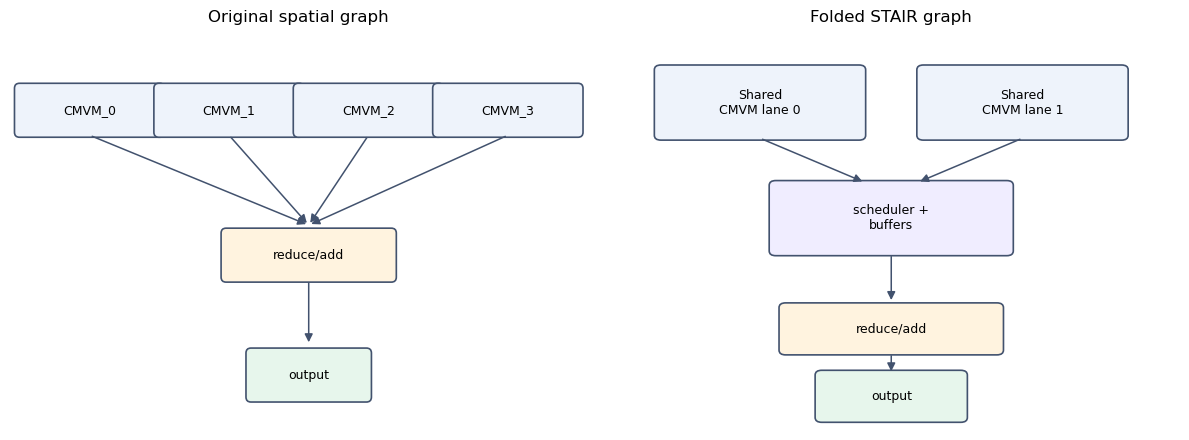

In [9]:
def draw_box(ax, xy, text, width=1.45, height=0.48, fc="#eef3fb", ec="#42526e"):
    x, y = xy
    patch = FancyBboxPatch((x - width/2, y - height/2), width, height,
                           boxstyle="round,pad=0.03,rounding_size=0.05",
                           linewidth=1.2, edgecolor=ec, facecolor=fc)
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=9)


def arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12,
                                 linewidth=1.1, color="#42526e"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.set_title("Original spatial graph")
for i, x in enumerate([0.8, 2.2, 3.6, 5.0]):
    draw_box(ax, (x, 3.2), f"CMVM_{i}")
    arrow(ax, (x, 2.95), (3.0, 2.05))
draw_box(ax, (3.0, 1.75), "reduce/add", width=1.7, fc="#fff3df")
arrow(ax, (3.0, 1.5), (3.0, 0.85))
draw_box(ax, (3.0, 0.55), "output", width=1.2, fc="#e7f6ec")
ax.set_xlim(0, 5.8); ax.set_ylim(0, 4); ax.axis("off")

ax = axes[1]
ax.set_title("Folded STAIR graph")
draw_box(ax, (1.2, 3.25), "Shared\nCMVM lane 0", width=1.55, height=0.72)
draw_box(ax, (3.2, 3.25), "Shared\nCMVM lane 1", width=1.55, height=0.72)
draw_box(ax, (2.2, 2.05), "scheduler +\nbuffers", width=1.8, height=0.72, fc="#f0edff")
draw_box(ax, (2.2, 0.9), "reduce/add", width=1.65, fc="#fff3df")
draw_box(ax, (2.2, 0.2), "output", width=1.1, fc="#e7f6ec")
arrow(ax, (1.2, 2.88), (2.0, 2.42)); arrow(ax, (3.2, 2.88), (2.4, 2.42))
arrow(ax, (2.2, 1.68), (2.2, 1.17)); arrow(ax, (2.2, 0.65), (2.2, 0.43))
ax.set_xlim(0, 4.4); ax.set_ylim(-0.15, 4); ax.axis("off")
plt.tight_layout(); plt.show()

## Figure 2: Schedule Legality Diagram

# 2. Design-Space Exploration

In [10]:
dse_params = pd.DataFrame([
    {"Parameter": "Fold factor", "Values explored": ", ".join(map(str, FOLD_FACTORS)), "Meaning": "Temporal reuse factor stamped into the STAIR fold plan"},
    {"Parameter": "Lane count", "Values explored": "Derived by fold plan", "Meaning": "Physical lanes retained for each fold group"},
    {"Parameter": "Scheduling policy", "Values explored": "Current scheduler", "Meaning": "Resource-constrained schedule over expanded STAIR tasks"},
    {"Parameter": "Reuse policy", "Values explored": "Fold-plan structural reuse", "Meaning": "Which operations share hardware resources"},
    {"Parameter": "Target clock", "Values explored": f"{TARGET_FMAX_HZ/1e6:.0f} MHz", "Meaning": "Throughput conversion for STAIR estimates"},
])
dse_params

,Parameter,Values explored,Meaning
0,Fold factor,"1, 2, 4, 8, 16",Temporal reuse factor stamped into the STAIR f...
1,Lane count,Derived by fold plan,Physical lanes retained for each fold group
2,Scheduling policy,Current scheduler,Resource-constrained schedule over expanded ST...
3,Reuse policy,Fold-plan structural reuse,Which operations share hardware resources
4,Target clock,300 MHz,Throughput conversion for STAIR estimates


In [11]:
REP_FEATURES = 16
REP_PARTICLES = 128
rep_sweep = stair_df[(stair_df["features"] == REP_FEATURES) & (stair_df["particles"] == REP_PARTICLES)].copy()
rep_sweep["latency_ns_at_target"] = rep_sweep["latency_cycles"] * (1e9 / TARGET_FMAX_HZ)
rep_sweep[["design", "fold_factor", "pipeline_status", "error_message", "lanes", "stair_lut", "stair_ff", "latency_cycles", "latency_ns_at_target", "ii", "correctness_passed"]]

,design,fold_factor,pipeline_status,error_message,lanes,stair_lut,stair_ff,latency_cycles,latency_ns_at_target,ii,correctness_passed
45,Spatial baseline,1,ok,,128,227929.0,185189.0,59,196.666667,1,True
46,Folded-2,2,ok,,64,140481.0,120949.0,64,213.333333,2,True
47,Folded-4,4,ok,,32,88558.0,68525.0,66,220.000000,4,True
48,Folded-8,8,ok,,16,60963.0,42363.0,72,240.000000,8,True
49,Folded-16,16,ok,,8,46822.0,28859.0,86,286.666667,16,True


## Graph Topology Summary by Model

This table records the heterograph sizes for every benchmark model in `real_df`, then summarizes how task-graph size changes across the explored fold factors.


In [12]:
def _graph_node_count(graph) -> int:
    return len(getattr(graph, "vertices", ()) or ())


def _graph_edge_count(graph) -> int:
    return len(getattr(graph, "edges", ()) or ())


def _fold_axes_summary(design) -> str:
    axes = sorted({
        tuple(group.axes)
        for group in (getattr(design.fold_plan, "groups", ()) or ())
        if tuple(group.axes)
    })
    return ", ".join("(" + ",".join(map(str, axis_tuple)) + ")" for axis_tuple in axes) or "None"


def _task_graph_count(design) -> int:
    task_graph = getattr(design, "task_graph", None)
    if task_graph is not None and hasattr(task_graph, "vertices"):
        return _graph_node_count(task_graph)
    task_ir = getattr(design, "task_ir", None)
    return len(getattr(task_ir, "tasks", {}) or {})





def _summarise_graph_topology_for_model(model_row: pd.Series, fold_factors=FOLD_FACTORS) -> pd.DataFrame:
    model = load_keras_model(REPO / model_row.model_artifact)
    nn_graph = build_nn_ir_graph(model)

    task_count_by_fold = {}
    successful_designs = {}
    errors = {}
    for fold_factor in fold_factors:
        try:
            design = evaluate_folded_design(nn_graph, model, fold_factor=int(fold_factor))
            _apply_styles(nn_graph, design)
            successful_designs[int(fold_factor)] = design
            task_count_by_fold[int(fold_factor)] = _task_graph_count(design)
        except Exception as exc:
            errors[int(fold_factor)] = f"{type(exc).__name__}: {str(exc).splitlines()[0]}"
            task_count_by_fold[int(fold_factor)] = np.nan

    if not successful_designs:
        raise RuntimeError(f"No graph topology summary available for {model_row.model_artifact}: {errors}")

    topology_fold = min(successful_designs)
    topology_design = successful_designs[topology_fold]
    folded_designs = {
        fold: design
        for fold, design in successful_designs.items()
        if fold > 1 and getattr(design.fold_plan, "groups", ())
    }
    if folded_designs:
        fold_summary_design = folded_designs[max(folded_designs)]
    else:
        fold_summary_design = topology_design
    fold_group_count = len(getattr(fold_summary_design.fold_plan, "groups", ()) or ())

    valid_task_counts = {
        fold_factor: task_count
        for fold_factor, task_count in task_count_by_fold.items()
        if pd.notna(task_count)
    }
    min_task_fold, min_task_count = min(
        valid_task_counts.items(),
        key=lambda item: (item[1], item[0]),
    )
    max_task_fold, max_task_count = max(
        valid_task_counts.items(),
        key=lambda item: (item[1], item[0]),
    )

    row = {
        "Benchmark": model_row.feature_set,
        "Model size": f"{int(model_row.particles)} particles x {int(model_row.features)} features",
        "NN-IR nodes": _graph_node_count(nn_graph),
        "NN-IR edges": _graph_edge_count(nn_graph),
        "Sched-IR nodes": _graph_node_count(topology_design.sched_graph),
        "Sched-IR edges": _graph_edge_count(topology_design.sched_graph),
        "Fold groups": fold_group_count,
        "Fold axes": _fold_axes_summary(fold_summary_design),
        "Min task count": min_task_count,
        "Min task count fold": min_task_fold,
        "Max task count": max_task_count,
        "Max task count fold": max_task_fold,
        "Max fold factor": max(task_count_by_fold),
    }
    return pd.DataFrame([row])


def _summarise_all_graph_topologies() -> pd.DataFrame:
    rows = []
    for _, model_row in real_df.iterrows():
        rows.append(_summarise_graph_topology_for_model(model_row))
    return pd.concat(rows, ignore_index=True)


graph_topology_summary_all_models = _summarise_all_graph_topologies()
graph_topology_summary_all_models


,Benchmark,Model size,NN-IR nodes,NN-IR edges,Sched-IR nodes,Sched-IR edges,Fold groups,Fold axes,Min task count,Min task count fold,Max task count,Max task count fold,Max fold factor
0,3-feature,8 particles x 3 features,12,12,11,11,1,(1),11,1,55,16,16
1,3-feature,16 particles x 3 features,12,12,11,11,1,(1),11,1,103,16,16
2,3-feature,32 particles x 3 features,12,12,11,11,1,(1),11,1,103,16,16
3,3-feature,64 particles x 3 features,12,12,11,11,1,(1),11,1,103,16,16
4,3-feature,128 particles x 3 features,12,12,11,11,1,(1),11,1,103,16,16
5,16-feature,8 particles x 16 features,12,12,11,11,1,(1),11,1,55,16,16
6,16-feature,16 particles x 16 features,12,12,11,11,1,(1),11,1,103,16,16
7,16-feature,32 particles x 16 features,12,12,11,11,1,(1),11,1,103,16,16
8,16-feature,64 particles x 16 features,12,12,11,11,1,(1),11,1,103,16,16
9,16-feature,128 particles x 16 features,12,12,11,11,1,(1),11,1,103,16,16


## Figure 3: STAIR LUT Estimate Versus Fold Factor

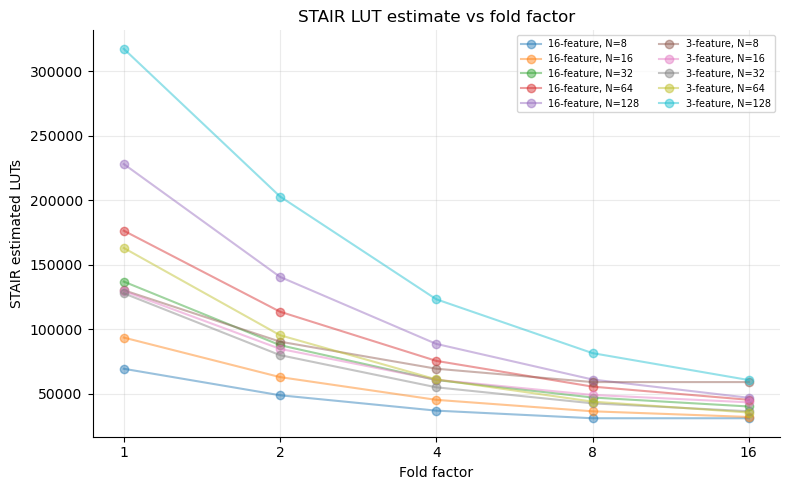

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ok_df = stair_df[stair_df["pipeline_status"] == "ok"].copy()
for (feature_set, particles), grp in ok_df.groupby(["feature_set", "particles"]):
    grp = grp.sort_values("fold_factor")
    ax.plot(grp["fold_factor"], grp["stair_lut"], marker="o", alpha=0.45, label=f"{feature_set}, N={particles}")
ax.set_xscale("log", base=2)
ax.set_xticks(FOLD_FACTORS, FOLD_FACTORS)
ax.set_xlabel("Fold factor")
ax.set_ylabel("STAIR estimated LUTs")
ax.set_title("STAIR LUT estimate vs fold factor")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## Figure 4: STAIR Latency Versus Fold Factor

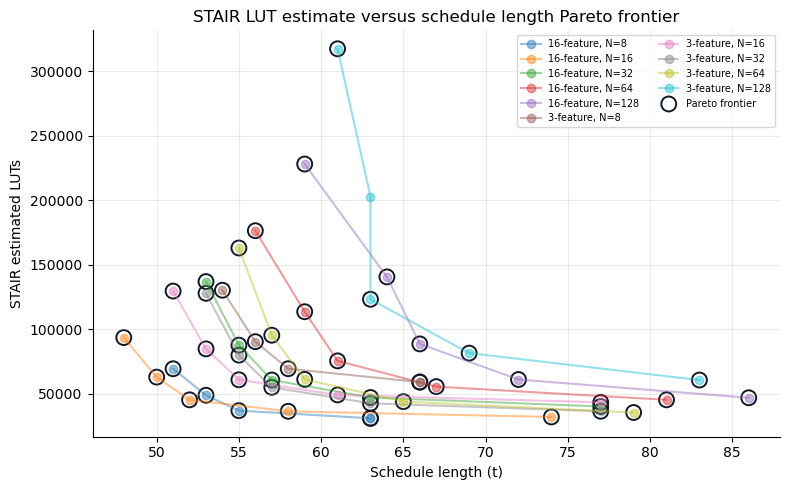

In [14]:
LATENCY_BUDGET_NS = 150
plot_df = stair_df[stair_df["pipeline_status"] == "ok"].copy()
plot_df["schedule_length_t"] = plot_df["latency_cycles"]
plot_df["latency_ns_at_target"] = plot_df["latency_cycles"] * (1e9 / TARGET_FMAX_HZ)


def pareto_mask(frame: pd.DataFrame, *, x: str, y: str = "stair_lut") -> pd.Series:
    values = frame[[x, y]].to_numpy(dtype=float)
    mask = np.ones(len(frame), dtype=bool)
    for i, (x_value, y_value) in enumerate(values):
        dominated = (
            (values[:, 0] <= x_value)
            & (values[:, 1] <= y_value)
            & ((values[:, 0] < x_value) | (values[:, 1] < y_value))
        ).any()
        mask[i] = not dominated
    return pd.Series(mask, index=frame.index)

plot_df["pareto"] = pareto_mask(plot_df, x="schedule_length_t")
for _, group in plot_df.groupby(["feature_set", "particles"]):
    plot_df.loc[group.index, "pareto"] = pareto_mask(plot_df.loc[group.index], x="schedule_length_t")
frontier = plot_df[plot_df["pareto"]].sort_values("schedule_length_t")

fig, ax = plt.subplots(figsize=(8, 5))
for (feature_set, particles), grp in plot_df.groupby(["feature_set", "particles"]):
    grp = grp.sort_values("schedule_length_t")
    ax.plot(grp["schedule_length_t"], grp["stair_lut"], marker="o", alpha=0.45, label=f"{feature_set}, N={particles}")
ax.scatter(
    frontier["schedule_length_t"],
    frontier["stair_lut"],
    s=115,
    facecolors="none",
    edgecolors="#111827",
    linewidths=1.4,
    label="Pareto frontier",
)
ax.set_xlabel("Schedule length (t)")
ax.set_ylabel("STAIR estimated LUTs")
ax.set_title("STAIR LUT estimate versus schedule length Pareto frontier")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


## Figure 5: Mean Sync Wait Versus Fold Factor

This plot shows the post-schedule sync wait introduced by folding. Each panel fixes the feature count; each curve is one particle count.


In [ ]:
mean_sync_wait_by_fold_df = (
    stair_df[stair_df["pipeline_status"].eq("ok")]
    .dropna(subset=["fold_factor", "particles", "mean_sync_wait_cycles"])
    .sort_values(["feature_set", "particles", "fold_factor"])
    .copy()
)

def _feature_set_sort_key(feature_set):
    match = re.match(r"(\d+)", str(feature_set))
    return int(match.group(1)) if match else str(feature_set)


feature_sets = sorted(mean_sync_wait_by_fold_df["feature_set"].dropna().unique(), key=_feature_set_sort_key)
fig, axes = plt.subplots(
    1,
    len(feature_sets),
    figsize=(5.2 * len(feature_sets), 5.2),
    sharey=True,
    squeeze=False,
)
axes = axes[0]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for feature_set, ax in zip(feature_sets, axes):
    feature_frame = mean_sync_wait_by_fold_df[
        mean_sync_wait_by_fold_df["feature_set"].eq(feature_set)
    ]
    for idx, particles in enumerate(sorted(feature_frame["particles"].dropna().astype(int).unique())):
        group = feature_frame[feature_frame["particles"].astype(int).eq(particles)].sort_values("fold_factor")
        ax.plot(
            group["fold_factor"],
            group["mean_sync_wait_cycles"],
            marker="o",
            linewidth=1.8,
            color=color_cycle[idx % len(color_cycle)],
            label=f"N={particles}",
        )
    ax.set_xscale("log", base=2)
    ax.set_xticks(FOLD_FACTORS, FOLD_FACTORS)
    ax.set_xlabel("Fold factor")
    ax.set_title(feature_set)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="Particles", frameon=True, fontsize=8)

axes[0].set_ylabel("Mean sync wait cycles")
fig.suptitle("JEDI-linear Mean Sync Wait Cycles versus Fold Factor", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.94])
jedi_mean_sync_wait_vs_fold_factor_path = REPO / "IR" / "jedi_mean_sync_wait_vs_fold_factor_by_particles.png"
fig.savefig(jedi_mean_sync_wait_vs_fold_factor_path, dpi=200)
jedi_mean_sync_wait_vs_fold_factor_path


# 3. Comparison Against Real Results

For LUT validation, compare only the unfolded STAIR estimate (`fold_factor == 1`) against real spatial hardware. Folded LUT points are design-space estimates and should not be compared directly against a spatial hardware synthesis run unless those folded designs are also synthesised.

In [15]:
baseline_stair = stair_df[(stair_df["fold_factor"] == 1) & (stair_df["pipeline_status"] == "ok")].copy()
validation_df = real_df.merge(
    baseline_stair[["feature_set", "particles", "stair_lut", "stair_ff", "latency_cycles", "ii", "correctness_passed"]],
    on=["feature_set", "particles"],
    how="left",
)
validation_df["stair_lut_error_vs_hls_pct"] = (validation_df["stair_lut"] - validation_df["lut"]).abs() / validation_df["lut"] * 100
validation_df["da4ml_lut_error_vs_hls_pct"] = (validation_df["da4ml_lut_estimate"] - validation_df["lut"]).abs() / validation_df["lut"] * 100
validation_df[[
    "feature_set", "particles", "lut", "stair_lut", "stair_lut_error_vs_hls_pct",
    "da4ml_lut_estimate", "da4ml_lut_error_vs_hls_pct", "correctness_passed",
]]


,feature_set,particles,lut,stair_lut,stair_lut_error_vs_hls_pct,da4ml_lut_estimate,da4ml_lut_error_vs_hls_pct,correctness_passed
0,3-feature,8,136497,130150.0,4.649919,129316.0,5.260921,True
1,3-feature,16,136440,129494.0,5.090882,127752.5,6.367268,True
2,3-feature,32,135939,127758.0,6.018140,126214.0,7.153944,True
3,3-feature,64,163904,162885.0,0.621705,158211.5,3.473070,True
4,3-feature,128,295715,317202.0,7.266118,300589.0,1.648209,True
5,16-feature,8,71930,69300.0,3.656333,69071.0,3.974698,True
6,16-feature,16,98760,93462.0,5.364520,91407.5,7.444816,True
7,16-feature,32,146655,136839.0,6.693260,132781.0,9.460298,False
8,16-feature,64,192063,176269.0,8.223343,169650.5,11.669348,True
9,16-feature,128,242979,227929.0,6.193951,218614.5,10.027410,True


In [16]:
# average stair error 
avg_stair_error = validation_df["stair_lut_error_vs_hls_pct"].mean()
# average da4ml error
avg_da4ml_error = validation_df["da4ml_lut_error_vs_hls_pct"].mean()
print(f"Average STAIR LUT error vs HLS: {avg_stair_error:.1f}%")
print(f"Average DA4ML LUT estimate error vs HLS: {avg_da4ml_error:.1f}%")


Average STAIR LUT error vs HLS: 5.4%
Average DA4ML LUT estimate error vs HLS: 6.6%


PosixPath('/Users/sriharshavitta/Projects/CMIR/IR/jedi_luts_vs_particles_by_feature.png')

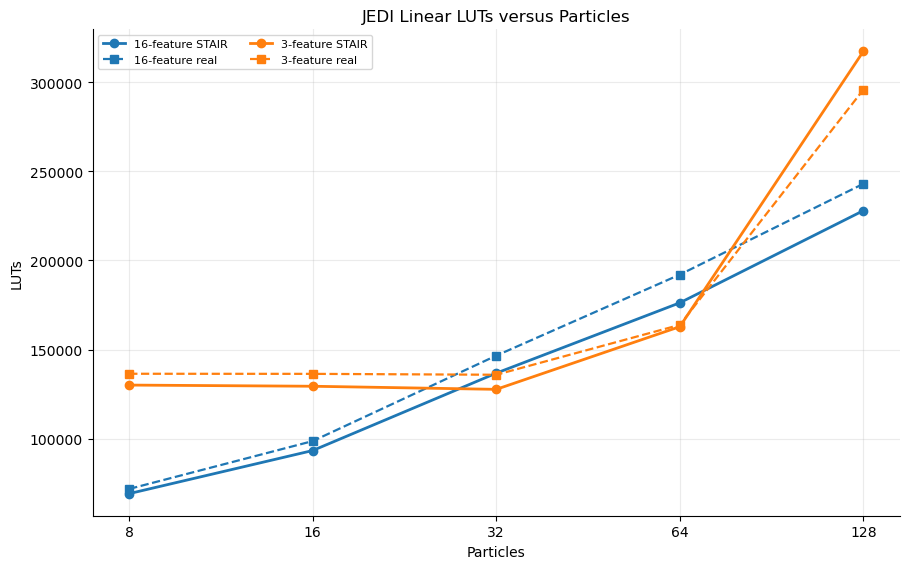

In [17]:
jedi_lut_by_particles_df = (
    validation_df.dropna(subset=["particles", "stair_lut", "lut"])
    .sort_values(["features", "particles"])
    .copy()
)

fig, ax = plt.subplots(figsize=(9.2, 5.8))
feature_sets = sorted(jedi_lut_by_particles_df["feature_set"].dropna().unique())
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, feature_set in enumerate(feature_sets):
    group = jedi_lut_by_particles_df[jedi_lut_by_particles_df["feature_set"].eq(feature_set)].sort_values("particles")
    color = color_cycle[idx % len(color_cycle)]

    ax.plot(
        group["particles"],
        group["stair_lut"],
        marker="o",
        linewidth=2.0,
        color=color,
        label=f"{feature_set} STAIR",
    )

    real_group = group.dropna(subset=["lut"])
    if not real_group.empty:
        ax.plot(
            real_group["particles"],
            real_group["lut"],
            marker="s",
            linestyle="--",
            linewidth=1.6,
            color=color,
            label=f"{feature_set} real",
        )

ax.set_xscale("log", base=2)
particle_ticks = sorted(jedi_lut_by_particles_df["particles"].dropna().astype(int).unique())
ax.set_xticks(particle_ticks, particle_ticks)
ax.set_xlabel("Particles")
ax.set_ylabel("LUTs")
ax.set_title("JEDI Linear LUTs versus Particles")
ax.legend(frameon=True, ncols=2, fontsize=8)
fig.tight_layout()
jedi_luts_vs_particles_path = REPO / "IR" / "jedi_luts_vs_particles_by_feature.png"
fig.savefig(jedi_luts_vs_particles_path, dpi=200)
jedi_luts_vs_particles_path

## JEDI-linear STAIR LUT tradeoff proxy plots


{'plot_a_lut_vs_scheduled_latency': PosixPath('/Users/sriharshavitta/Projects/CMIR/IR/jedi_lut_vs_scheduled_latency.png'),
 'plot_b_lut_vs_ii_proxy_per_temporal_step': PosixPath('/Users/sriharshavitta/Projects/CMIR/IR/jedi_lut_vs_ii_proxy_per_temporal_step.png'),
 'plot_c_lut_vs_normalised_throughput_proxy': PosixPath('/Users/sriharshavitta/Projects/CMIR/IR/jedi_lut_vs_normalised_throughput_proxy.png')}

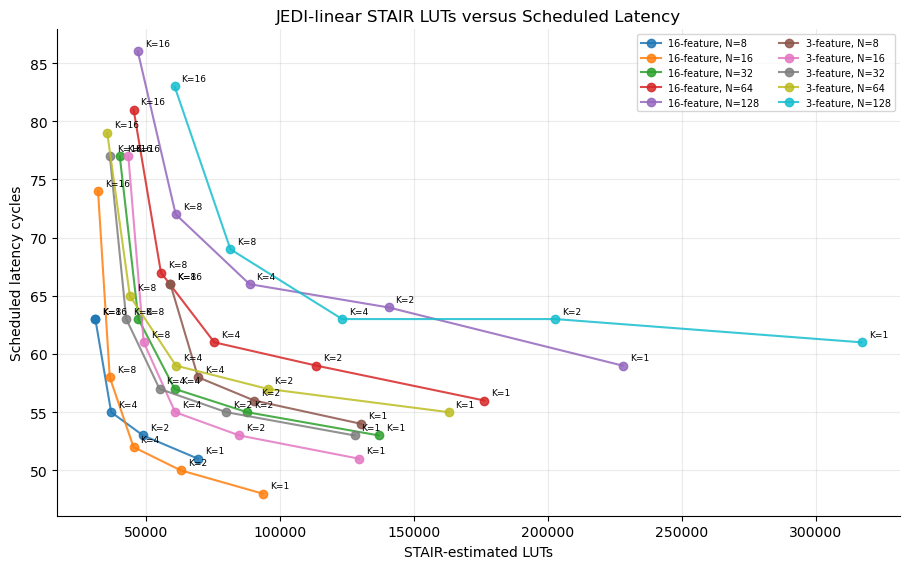

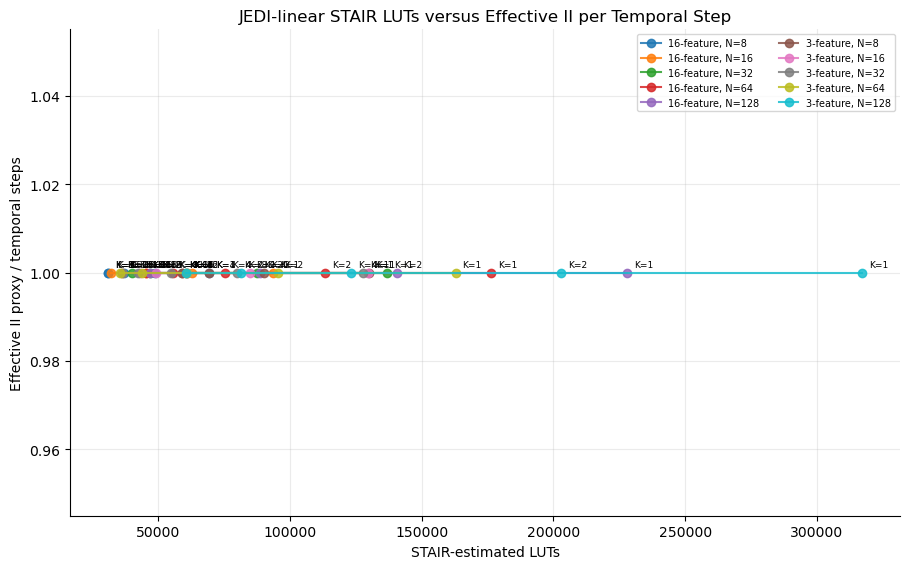

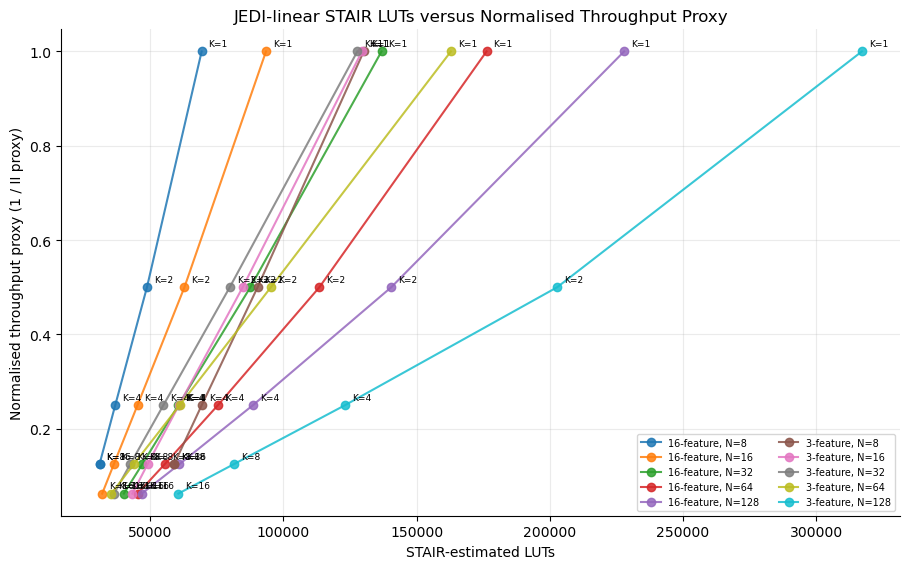

In [18]:
jedi_tradeoff_df = (
    stair_df[stair_df["pipeline_status"].eq("ok")]
    .dropna(subset=["stair_lut", "latency_cycles", "ii", "max_temporal_steps"])
    .sort_values(["feature_set", "particles", "fold_factor"])
    .copy()
)
jedi_tradeoff_df["ii_proxy_per_temporal_step"] = (
    jedi_tradeoff_df["ii"] / jedi_tradeoff_df["max_temporal_steps"].clip(lower=1)
)
jedi_tradeoff_df["normalised_throughput_proxy"] = 1 / jedi_tradeoff_df["ii"].replace(0, np.nan)


def plot_jedi_tradeoff(
    frame: pd.DataFrame,
    *,
    y_col: str,
    ylabel: str,
    title: str,
    output_path: Path,
    x_col="stair_lut",
    xlabel="STAIR-estimated LUTs",
):
    fig, ax = plt.subplots(figsize=(9.2, 5.8))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for idx, ((feature_set, particles), group) in enumerate(frame.groupby(["feature_set", "particles"])):
        group = group.sort_values("fold_factor")
        color = color_cycle[idx % len(color_cycle)]
        ax.plot(
            group[x_col],
            group[y_col],
            marker="o",
            linewidth=1.5,
            alpha=0.85,
            color=color,
            label=f"{feature_set}, N={int(particles)}",
        )
        for _, row in group.iterrows():
            ax.annotate(
                f"K={int(row['fold_factor'])}",
                (row[x_col], row[y_col]),
                textcoords="offset points",
                xytext=(5, 4),
                fontsize=6.5,
            )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True, ncols=2, fontsize=7)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    return output_path


jedi_lut_vs_scheduled_latency_path = plot_jedi_tradeoff(
    jedi_tradeoff_df,
    y_col="latency_cycles",
    ylabel="Scheduled latency cycles",
    title="JEDI-linear STAIR LUTs versus Scheduled Latency",
    output_path=REPO / "IR" / "jedi_lut_vs_scheduled_latency.png",
)
jedi_lut_vs_ii_proxy_per_temporal_step_path = plot_jedi_tradeoff(
    jedi_tradeoff_df,
    y_col="ii_proxy_per_temporal_step",
    ylabel="Effective II proxy / temporal steps",
    title="JEDI-linear STAIR LUTs versus Effective II per Temporal Step",
    output_path=REPO / "IR" / "jedi_lut_vs_ii_proxy_per_temporal_step.png",
)
jedi_lut_vs_normalised_throughput_proxy_path = plot_jedi_tradeoff(
    jedi_tradeoff_df,
    y_col="normalised_throughput_proxy",
    ylabel="Normalised throughput proxy (1 / II proxy)",
    title="JEDI-linear STAIR LUTs versus Normalised Throughput Proxy",
    output_path=REPO / "IR" / "jedi_lut_vs_normalised_throughput_proxy.png",
)

jedi_tradeoff_plot_paths = {
    "plot_a_lut_vs_scheduled_latency": jedi_lut_vs_scheduled_latency_path,
    "plot_b_lut_vs_ii_proxy_per_temporal_step": jedi_lut_vs_ii_proxy_per_temporal_step_path,
    "plot_c_lut_vs_normalised_throughput_proxy": jedi_lut_vs_normalised_throughput_proxy_path,
}
jedi_tradeoff_plot_paths


## Figure 8: Estimated Versus Synthesised LUTs

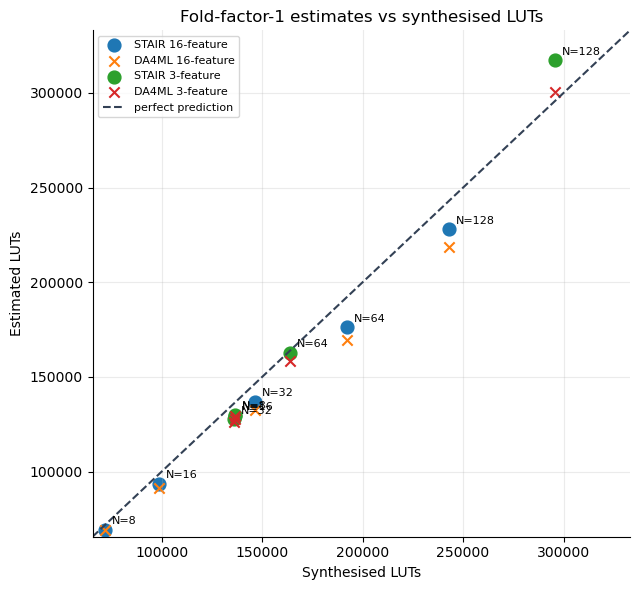

In [19]:
plot_validation = validation_df.dropna(subset=["stair_lut", "da4ml_lut_estimate", "lut"]).copy()
if plot_validation.empty:
    print("No successful fold-factor-1 STAIR estimates available for validation scatter.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for feature_set, grp in plot_validation.groupby("feature_set"):
        ax.scatter(grp["lut"], grp["stair_lut"], s=85, label=f"STAIR {feature_set}")
        ax.scatter(grp["lut"], grp["da4ml_lut_estimate"], s=55, marker="x", label=f"DA4ML {feature_set}")
        for _, r in grp.iterrows():
            ax.annotate(f"N={r.particles}", (r.lut, r.stair_lut), xytext=(5, 4), textcoords="offset points", fontsize=8)
    lo = min(plot_validation["lut"].min(), plot_validation["stair_lut"].min(), plot_validation["da4ml_lut_estimate"].min()) * 0.95
    hi = max(plot_validation["lut"].max(), plot_validation["stair_lut"].max(), plot_validation["da4ml_lut_estimate"].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], color="#334155", linestyle="--", label="perfect prediction")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Synthesised LUTs")
    ax.set_ylabel("Estimated LUTs")
    ax.set_title("Fold-factor-1 estimates vs synthesised LUTs")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

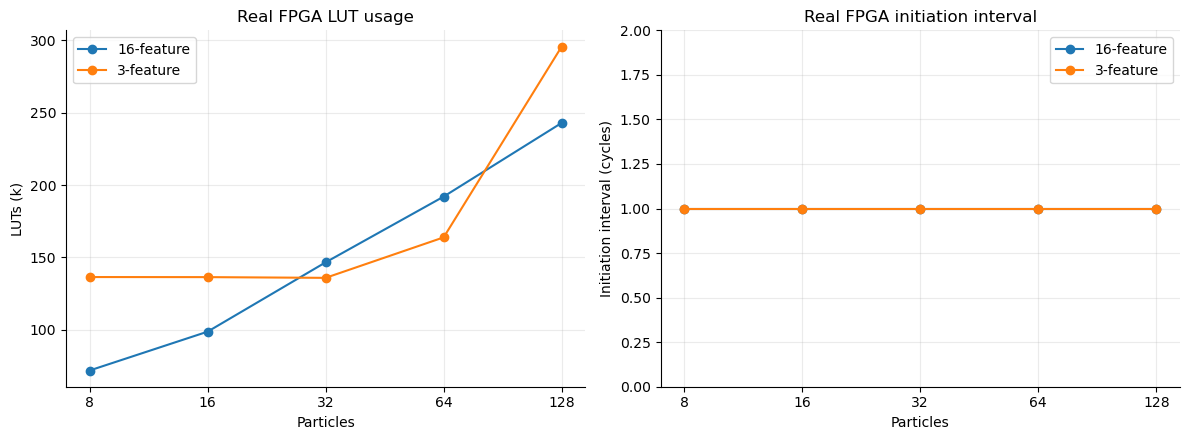

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for feature_set, grp in real_df.groupby("feature_set"):
    grp = grp.sort_values("particles")
    axes[0].plot(grp["particles"], grp["lut_k"], marker="o", label=feature_set)
    axes[1].plot(grp["particles"], grp["ii"], marker="o", label=feature_set)
axes[0].set_xlabel("Particles")
axes[0].set_ylabel("LUTs (k)")
axes[0].set_title("Real FPGA LUT usage")
axes[1].set_xlabel("Particles")
axes[1].set_ylabel("Initiation interval (cycles)")
axes[1].set_title("Real FPGA initiation interval")
axes[1].set_ylim(0, max(2, real_df["ii"].max() + 1))
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks([8, 16, 32, 64, 128], [8, 16, 32, 64, 128])
    ax.legend()
plt.tight_layout(); plt.show()

In [21]:
base = real_df[(real_df["features"] == REP_FEATURES) & (real_df["particles"] == REP_PARTICLES)].iloc[0]
selected = rep_sweep[(rep_sweep["pipeline_status"] == "ok") & (rep_sweep["correctness_passed"])].sort_values("stair_lut").head(4).copy()
selected["latency_ns_at_target"] = selected["latency_cycles"] * (1e9 / TARGET_FMAX_HZ)
rows = [{
    "design": "Real DA4ML spatial baseline",
    "fold_factor": 1,
    "lut": int(base.lut),
    "lut_reduction_vs_real": "--",
    "ff": int(base.ff),
    "latency_ns": round(base.latency_ns, 1),
    "ii": int(base.ii),
    "correctness_passed": True,
}]
for _, r in selected.iterrows():
    rows.append({
        "design": r.design,
        "fold_factor": int(r.fold_factor),
        "lut": int(round(r.stair_lut)),
        "lut_reduction_vs_real": f"{(1 - r.stair_lut / base.lut) * 100:.1f}%",
        "ff": int(round(r.stair_ff)),
        "latency_ns": round(r.latency_ns_at_target, 1),
        "ii": int(r.ii),
        "correctness_passed": bool(r.correctness_passed),
    })
baseline_vs_stair = pd.DataFrame(rows)
baseline_vs_stair

,design,fold_factor,lut,lut_reduction_vs_real,ff,latency_ns,ii,correctness_passed
0,Real DA4ML spatial baseline,1,242979,--,110726,109.5,1,True
1,Folded-16,16,46822,80.7%,28859,286.7,16,True
2,Folded-8,8,60963,74.9%,42363,240.0,8,True
3,Folded-4,4,88558,63.6%,68525,220.0,4,True
4,Folded-2,2,140481,42.2%,120949,213.3,2,True


# Discussion Prompts

- Correctness should be reported for every fold factor.
- LUT estimate agreement should be reported against the real synthesis results only for `fold_factor == 1` unless folded designs are also synthesised.
- Folded estimates are still useful for design-space exploration: they show the predicted area/latency/II trade-off before running synthesis.